# Emergency Triage Code Prediction from Vital-Sign **Time Windows**

Instead of classifying a single snapshot, we feed the model a **short window of consecutive vital-sign readings** and predict the patient's **triage code** on the Italian **5-level numeric scale**. This is done by using a short time window that lets the model exploit the *temporal pattern* (level **and** variability/trend), which a single instant cannot capture. 

**Italian 5-level triage scale** (national guidelines). Lower number = more urgent:

| Code | Colour | Meaning | Target time |
|---|---|---|---|
| **1** | Red | Emergency (life-threatening) | immediate |
| **2** | Orange | Very urgent | ~15 min |
| **3** | Blue | Deferrable urgency | ~60 min |
| **4** | Green | Minor urgency | ~120 min |
| **5** | White | Non-urgent | ~240 min |

Internally the classes are 0-indexed (`index = code − 1`): `index 0 → Code 1 (Red) … index 4 → Code 5 (White)`.

**window-size study.** Rather than committing to a single window length, the notebook trains the same 1D-CNN for **several window sizes**, compares the main indices (accuracy, macro precision/recall/F1, Code-1 recall, footprint) **before the Contiki translation** (float Keras model) and **after it** (the int8 TFLite-Micro model, exactly what the nRF52840 executes), and only then emits the deployment artifacts for the chosen window.

## 1. Setup

In [1]:
!pip install tensorflow[and-cuda] vitaldb scikit-learn seaborn

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

import vitaldb

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')
print('TensorFlow', tf.__version__)  # Sanity check

# Let TensorFlow use the GPU memory
for _gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass
print('GPUs:', tf.config.list_physical_devices('GPU') or 'none (CPU run)')

TensorFlow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Download

**Six vital signs** feed the model: `HR` (bpm), `SBP`/`DBP` (mmHg), `RR` (breaths/min), `SpO2` (%), `Temp` (°C).

### Data sources
- **VitalDB (real).** The [VitalDB open dataset](https://vitaldb.net) holds intraoperative recordings from 6,388 surgical cases. We pull the six numeric tracks through the `vitaldb` API.

### Labels for the real data — a NEWS2 proxy
VitalDB has **no triage label**, so for the real-data path we derive one: a simplified **NEWS2** (thanks Sara) early-warning score is computed per window and its aggregate is binned into the 5 triage levels (higher score → more urgent → lower code). 

### Window sizes under test
`WINDOW_SIZES = [10, 20, 30, 45, 60]` readings. At `SAMPLING_INTERVAL = 1 s` they span **10–60 s** of real time (the int8 window buffer stays tiny: `W × 6` bytes → 60–360 B). 

On the MAX30102 the sampling frequency is 100 Hz but it is referred to the raw PPG waveform ADC rate. HR/SpO2 are computed from a window of that signal and are output at 1 Hz. This is why we choose to select `SAMPLING_INTERVAL = 1 s`.

To avoid re-downloading from the API once per window size, each case is fetched **once**, gap-filled, cached to disk, and then sliced locally into windows of every size.

In [3]:
SAMPLING_INTERVAL = 1

WINDOW_SIZES    = [10, 20, 30, 45, 60]   # readings per window (= seconds at 1 Hz)
BASELINE_WINDOW = 30                     # used by the EDA plots and as default deployment choice

FEATURES    = ['HR', 'SBP', 'DBP', 'RR', 'SpO2', 'Temp']
CODE_LABELS = ['1 - Red', '2 - Orange', '3 - Blue', '4 - Green', '5 - White']  # index 0..4
CODE_COLORS = ['#d64545', '#e08a1e', '#3a7bd5', '#2e9e5b', '#9e9e9e']

USE_CLASS_WEIGHTS = True   # Code 1 (Red) is rare -> balanced loss weights so it cannot be ignored
MAX_CASES         = None   # e.g. 300 for a quick smoke test of the whole notebook

In [4]:
# --- Proxy labels for the REAL data: NEWS2 early-warning score ---
# VitalDB has no triage label, so we score each window and bin the aggregate into
# the 5 levels. Higher aggregate -> more urgent -> lower code number -> lower index.
    
def label_from_window_batch(X, chunk=500_000):
    '''Vectorized + chunked: plain np.median (data is NaN-free by construction),
    processed in blocks to keep peak temporary memory bounded.'''
    out = np.empty(len(X), dtype=int)
    for i in range(0, len(X), chunk):
        m = np.median(X[i:i + chunk], axis=1)        # (chunk, 6)
        hr, sbp, rr, spo2, temp = m[:, 0], m[:, 1], m[:, 3], m[:, 4], m[:, 5]

        s_rr   = np.select([rr <= 8,  rr <= 11, rr <= 20, rr <= 24], [3, 1, 0, 2], default=3)
        s_spo2 = np.select([spo2 >= 96, spo2 >= 94, spo2 >= 92],      [0, 1, 2],    default=3)
        s_sbp  = np.select([sbp <= 90, sbp <= 100, sbp <= 110, sbp <= 219], [3, 2, 1, 0], default=3)
        s_hr   = np.select([hr <= 40, hr <= 50, hr <= 90, hr <= 110, hr <= 130], [3, 1, 0, 1, 2], default=3)
        s_temp = np.select([temp <= 35, temp <= 36, temp <= 38, temp <= 39], [3, 1, 0, 1], default=2)

        agg = s_rr + s_spo2 + s_sbp + s_hr + s_temp
        out[i:i + chunk] = np.select([agg >= 9, agg >= 7, agg >= 5, agg >= 2], [0, 1, 2, 3], default=4)
    return out

In [5]:
# --- Load the VitalDB open dataset ONCE, cache the per-case series, slice locally ---

TRACK_MAP = {
    'HR':   'Solar8000/HR',
    'SBP':  'Solar8000/ART_SBP',    
    'DBP':  'Solar8000/ART_DBP',    
    'RR':   'Solar8000/RR_CO2',     
    'SpO2': 'Solar8000/PLETH_SPO2',
    'Temp': 'Solar8000/BT',
}

FEATURE_DEFAULTS = np.array([80, 120, 78, 16, 97, 36.8], dtype=float)  # HR,SBP,DBP,RR,SpO2,Temp

SERIES_CACHE = 'vitaldb_series.npz'

def _ffill_bfill(a):
    '''Fill NaNs column-wise: back-fill leading gaps, forward-fill the rest.'''
    a = a.astype(float).copy()
    for j in range(a.shape[1]):
        col = a[:, j]
        good = np.where(~np.isnan(col))[0]
        if len(good) == 0:
            continue
        col[:good[0]] = col[good[0]]
        for i in range(good[0] + 1, len(col)):
            if np.isnan(col[i]):
                col[i] = col[i - 1]
        a[:, j] = col
    return a


def load_vitaldb_series(interval=SAMPLING_INTERVAL, max_cases=MAX_CASES, cache=SERIES_CACHE):
    '''Read every case that has the tracks and keep its FULL gap-filled series.
    Missing values are forward/back-filled; anything still missing (a track absent
    for a whole case) is imputed with a physiological default, so no data is ever
    discarded. The result is cached so the window-size sweep never re-downloads.'''
    if cache and os.path.exists(cache):
        d = np.load(cache)
        series = [d[k] for k in sorted(d.files, key=lambda s: int(s.split('_')[1]))]
        print(f'Loaded {len(series)} cached case series from {cache}')
        return series

    tracks  = [TRACK_MAP[f] for f in FEATURES]
    caseids = vitaldb.find_cases(tracks)
    if max_cases is not None:
        caseids = caseids[:max_cases]

    series, min_len = [], min(WINDOW_SIZES)
    for k, cid in enumerate(caseids, 1):
        try:
            arr = vitaldb.load_case(cid, tracks, interval=interval)
        except Exception:
            continue
        if arr is None or len(arr) < min_len:
            continue
        filled = _ffill_bfill(np.asarray(arr, dtype=float))
        filled = np.where(np.isnan(filled), FEATURE_DEFAULTS, filled)
        series.append(filled.astype(np.float32))
        if k % 250 == 0:
            print(f'  ...{k}/{len(caseids)} cases scanned, {len(series)} kept')

    if cache and len(series):
        np.savez_compressed(cache, **{f'case_{i}': s for i, s in enumerate(series)})
        print(f'Cached {len(series)} case series to {cache}')
    return series


def make_windows(series, window, stride=None):
    '''Slice every cached case into (window, features) segments; label everything at once.'''
    stride = max(1, window // 2) if stride is None else stride
    X_list = []
    for s_arr in series:
        if len(s_arr) < window:
            continue
        for s in range(0, len(s_arr) - window + 1, stride):
            X_list.append(s_arr[s:s + window])
    X = np.asarray(X_list, dtype=np.float32)
    y = label_from_window_batch(X)
    return X, y

In [ ]:
series = load_vitaldb_series()
if len(series) == 0:
    raise RuntimeError('No usable VitalDB cases — check internet')

# Baseline dataset (used by the EDA below; the sweep re-slices the series for every size)
WINDOW = BASELINE_WINDOW
STRIDE = WINDOW // 2
X, y = make_windows(series, WINDOW, STRIDE)

print('X shape     :', X.shape, '(windows, timesteps, features)')
dist = pd.Series(np.bincount(y, minlength=len(CODE_LABELS)), index=CODE_LABELS)
print('\nClass distribution:')
print(dist)

Loaded 3581 cached case series from vitaldb_series.npz
X shape     : (3304331, 30, 6) (windows, timesteps, features)

Class distribution:
1 - Red        162731
2 - Orange     119943
3 - Blue       316745
4 - Green     1331259
5 - White     1373653
dtype: int64


In [25]:
# --- Timing/footprint implied by each window size (the firmware must match the chosen one) ---
timing = pd.DataFrame({
    'window (readings)'    : WINDOW_SIZES,
    'span (s of real time)': [w * SAMPLING_INTERVAL for w in WINDOW_SIZES],
    'training stride'      : [max(1, w // 2) for w in WINDOW_SIZES],
    'int8 input buffer (B)': [w * len(FEATURES) for w in WINDOW_SIZES],
}).set_index('window (readings)')

print(f'Sensor sampling period : {SAMPLING_INTERVAL}s')
print('Time to the FIRST prediction after boot = the window span;')
print('afterwards the buffer can slide by 1 reading, so a new prediction every '
      f'{SAMPLING_INTERVAL}s regardless of the window size.')
timing

Sensor sampling period : 1s
Time to the FIRST prediction after boot = the window span;
afterwards the buffer can slide by 1 reading, so a new prediction every 1s regardless of the window size.


,span (s of real time),training stride,int8 input buffer (B)
window (readings),,,
10,10,5,60
20,20,10,120
30,30,15,180
45,45,22,270
60,60,30,360


## 3. Exploratory Data Analysis

Plots use the baseline `WINDOW = 30`; the sweep below re-slices the cached series for every size.

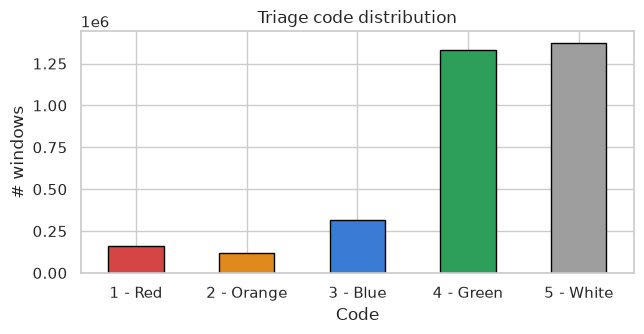

In [8]:
# Class distribution
ax = dist.plot(kind='bar', color=CODE_COLORS, edgecolor='black', figsize=(6.5, 3.5))
ax.set_title('Triage code distribution'); ax.set_xlabel('Code'); ax.set_ylabel('# windows')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

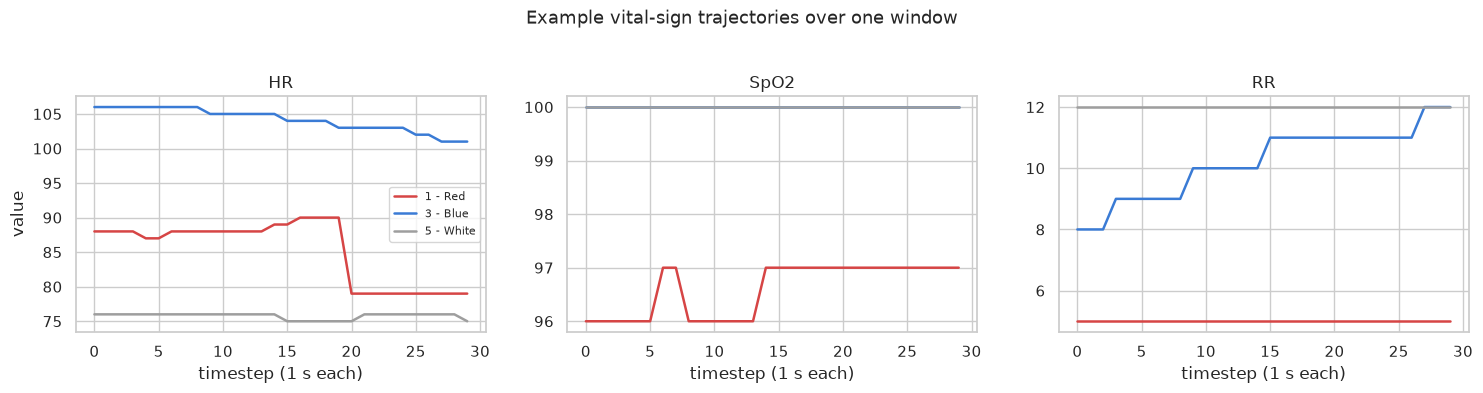

In [ ]:
# One example window per class for three key vitals — shows the TEMPORAL structure
show_codes = [0, 2, 4]   # Red, Blue, White
show_feats = ['HR', 'SpO2', 'RR']
# grab the first window of each shown class
examples = {c: X[np.where(y == c)[0][0]] for c in show_codes}
t = np.arange(WINDOW)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, feat in zip(axes, show_feats):
    j = FEATURES.index(feat)
    for c in show_codes:
        ax.plot(t, examples[c][:, j], color=CODE_COLORS[c], lw=1.8, label=CODE_LABELS[c])
    ax.set_title(feat); ax.set_xlabel(f'timestep ({SAMPLING_INTERVAL} s each)')
axes[0].set_ylabel('value'); axes[0].legend(fontsize=8)
plt.suptitle('Example vital-sign trajectories over one window', y=1.03, fontsize=13)
plt.tight_layout(); 
plt.show()

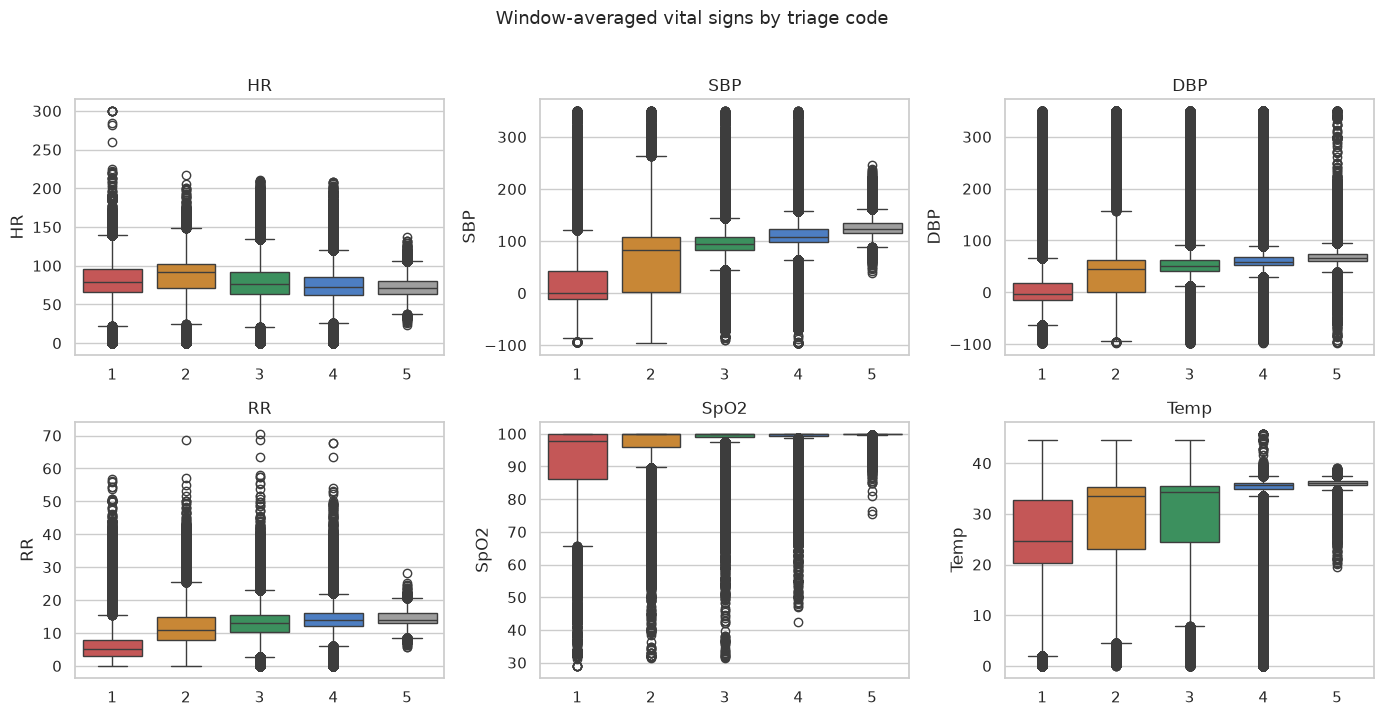

In [10]:
# Window-averaged features (one value per window) — for standard box/correlation views
win_mean = X.mean(axis=1)                       
mean_df = pd.DataFrame(win_mean, columns=FEATURES)
mean_df['Code'] = [CODE_LABELS[i] for i in y]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=mean_df, x='Code', y=feat, hue='Code', palette=CODE_COLORS,
                legend=False, ax=ax, order=CODE_LABELS)
    ax.set_xticklabels([c.split(' - ')[0] for c in CODE_LABELS])
    ax.set_title(feat); ax.set_xlabel('')
plt.suptitle('Window-averaged vital signs by triage code', y=1.02, fontsize=13)
plt.tight_layout();
plt.show()

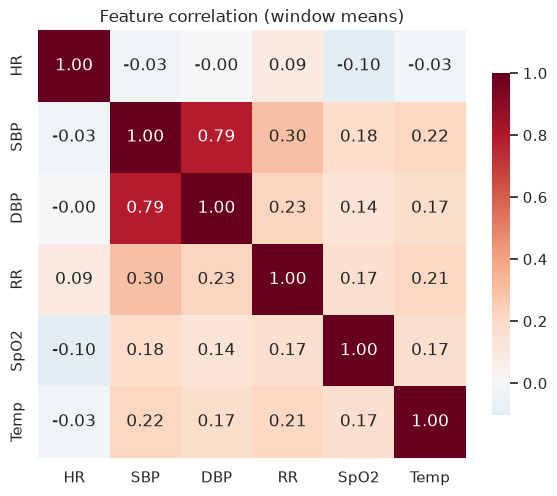

In [11]:
# Correlation of window-averaged features
plt.figure(figsize=(6, 5))
sns.heatmap(mean_df[FEATURES].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature correlation (window means)'); plt.tight_layout(); plt.show()

SBP and DBP have got an high value of correlation (around $79\%$). We choose to kept both because they are equaly important and the number of parameter is not too much high.

## 4. Parameterized pipeline — one experiment per window size

For **each** window size the very same pipeline runs end-to-end:

1. **Windowing** with `stride = window // 2` (50% overlap).
2. **Stratified split** 70 / 15 / 15 (keeps class ratios in every split — important because Code 1 is rare).
3. **Per-feature standardization**: mean/std computed over **all timesteps of the training windows only**, then applied to every window (fitting on training data only avoids leaking test statistics). Each window size gets **its own** constants — the deployed firmware must use the pair belonging to the chosen window.
4. **Model**: the same tiny 1D-CNN — `Conv1D(24, k=3) → MaxPool → Conv1D(16, k=3) → GlobalAveragePooling → Dense(16) → Dense(5, softmax)`. A CNN slides small kernels **along the time axis**, so it learns local temporal motifs (a rising heart rate, a dip in SpO2); `GlobalAveragePooling1D` (rather than `Flatten`) keeps the parameter count low and makes the exact same architecture valid for every window length — only the time axis changes.
5. **Training** with early stopping on `val_loss` (and balanced class weights, if `USE_CLASS_WEIGHTS`).
6. **Evaluation *before* the Contiki translation** — the float Keras model on the held-out test set.
7. **Translation for Contiki** — full-integer (int8) post-training quantization with TFLite Micro: representative dataset from training windows, int8 input/output as required by the MCU runtime.
8. **Evaluation *after* the translation** — the int8 interpreter run exactly as the microcontroller would, on the **same** test set, plus float ↔ int8 agreement.

Because the windowing changes, each window size produces a (slightly) different dataset: the comparison answers *"which window works best end-to-end"*, not *"which model wins on identical samples"*.

In [12]:
def build_model(window):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(window, len(FEATURES))),
        tf.keras.layers.Conv1D(24, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(16, kernel_size=3, activation='relu', padding='same'),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(len(CODE_LABELS), activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

build_model(BASELINE_WINDOW).summary()   # same architecture for every size, only the time axis changes

W0000 00:00:1788196047.889154    1428 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788196048.057332    1428 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 24)         │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 16)         │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,981 (7.74 KB)

 Trainable params: 1,981 (7.74 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def compute_metrics(y_true, y_pred):
    '''The headline indices: accuracy + macro precision/recall/F1 (imbalance-aware),
    plus the per-class breakdown — the recall on Code 1 (Red) is the safety-critical one.'''
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CODE_LABELS)), zero_division=0)
    return {
        'accuracy'        : accuracy_score(y_true, y_pred),
        'prec_macro'      : prec.mean(),
        'recall_macro'    : rec.mean(),      # == balanced accuracy
        'f1_macro'        : f1.mean(),
        'recall_per_class': rec,
        'f1_per_class'    : f1,
        'report'          : classification_report(y_true, y_pred,
                                                  labels=range(len(CODE_LABELS)),
                                                  target_names=CODE_LABELS,
                                                  digits=3, zero_division=0),
    }

In [14]:
def convert_int8(model, X_train_s):
    '''The Contiki translation: full-integer post-training quantization for TFLite Micro.'''
    def representative_dataset():
        # A few hundred real training windows to calibrate the quantization ranges
        for i in range(min(300, len(X_train_s))):
            yield [X_train_s[i:i+1]]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


def tflite_predict(tflite_bytes, windows_std):
    '''Run the int8 interpreter exactly as the microcontroller would.'''
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]
    in_scale,  in_zp  = inp['quantization']
    out_scale, out_zp = out['quantization']

    preds = np.empty(len(windows_std), dtype=int)
    for i in range(len(windows_std)):
        # quantize (clipped to the int8 range to avoid wrap-around on outliers)
        q = np.clip(np.round(windows_std[i:i+1] / in_scale + in_zp), -128, 127).astype(np.int8)
        interpreter.set_tensor(inp['index'], q)
        interpreter.invoke()
        o = interpreter.get_tensor(out['index'])[0].astype(np.float32)
        o = (o - out_zp) * out_scale                                          # dequantize
        preds[i] = o.argmax()
    return preds, (in_scale, in_zp, out_scale, out_zp)

In [15]:
def run_window_experiment(window, series):
    '''Windowing -> split -> standardize -> train -> float eval -> int8 conversion -> int8 eval.'''

    stride = max(1, window // 2)
    X_w, y_w = make_windows(series, window, stride)
    n_window = len(X_w)

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X_w, y_w, test_size=0.30, stratify=y_w, random_state=SEED
    )
    del X_w
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
    )
    del X_tmp

    X_test_head = X_test[:15].copy()

    flat = X_train.reshape(-1, len(FEATURES))
    feat_mean, feat_std = flat.mean(axis=0), flat.std(axis=0)
    std = lambda a: ((a - feat_mean) / feat_std).astype(np.float32)
    X_train, X_val, X_test = std(X_train), std(X_val), std(X_test)

    y_train_oh = tf.keras.utils.to_categorical(y_train, len(CODE_LABELS))
    y_val_oh   = tf.keras.utils.to_categorical(y_val,   len(CODE_LABELS))

    class_weight = None
    if USE_CLASS_WEIGHTS:
        present = np.unique(y_train)
        w = compute_class_weight('balanced', classes=present, y=y_train)
        class_weight = {int(c): float(v) for c, v in zip(present, w)}

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_model(window)
    early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                             restore_best_weights=True, verbose=0)

    backup = tf.keras.callbacks.BackupAndRestore(
        backup_dir=os.path.join('sweep_ckpt', f'backup_w{window}'))

    hist = model.fit(X_train, y_train_oh,
                     validation_data=(X_val, y_val_oh),
                     epochs=200, batch_size=128,
                     class_weight=class_weight,
                     callbacks=[early, backup], verbose=1)

    # --- BEFORE the Contiki translation: float Keras model ---
    keras_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    m_float = compute_metrics(y_test, keras_pred)

    # --- Translation for Contiki + AFTER: int8 TFLite Micro model, same test set ---
    tflite_bytes = convert_int8(model, X_train)
    int8_pred, quant = tflite_predict(tflite_bytes, X_test)
    m_int8 = compute_metrics(y_test, int8_pred)

    # --- Save models ---
    float_path = os.path.join('sweep_ckpt', f'float_w{window}.keras')
    model.save(float_path)

    int8_path = os.path.join('sweep_ckpt', f'int8_w{window}.tflite')
    with open(int8_path, 'wb') as f:
        f.write(tflite_bytes)

    return {
        'window': window, 'stride': stride,
        'n_windows': n_window, 'n_train': len(X_train), 'n_test': len(X_test),
        'epochs': len(hist.history['loss']),
        'history': {k: list(map(float, v)) for k, v in hist.history.items()},
        'feat_mean': feat_mean, 'feat_std': feat_std,
        'float': m_float, 'int8': m_int8,
        'agreement': float((keras_pred == int8_pred).mean()),
        'y_test': y_test, 'keras_pred': keras_pred, 'int8_pred': int8_pred,
        'X_test_head': X_test_head,
        'float_model_path': float_path,
        'int8_model_path':  int8_path,
        'size_bytes': len(tflite_bytes),
        'quant': quant,
    }

## 5. Run the sweep

One end-to-end experiment per window size.

In [16]:
results = {}

CKPT_DIR = 'sweep_ckpt'
os.makedirs(CKPT_DIR, exist_ok=True)


for w in WINDOW_SIZES:

    ck = os.path.join(CKPT_DIR, f'window_{w}.pkl')
    if os.path.exists(ck):                       # Already done
        with open(ck, 'rb') as f:
            results[w] = pickle.load(f)
        print(f'=== window = {w}: loaded from checkpoint, skipping ===')
        continue

    print(f'=== window = {w} readings ({w * SAMPLING_INTERVAL} s) ===')
    r = run_window_experiment(w, series)
    results[w] = r
    
    with open(ck, 'wb') as f: #Save
        pickle.dump(r, f)

    print(f"  windows: {r['n_windows']:,}   epochs: {r['epochs']}   int8 model: {r['size_bytes']/1024:.1f} KB")
    print(f"  BEFORE (float): acc {r['float']['accuracy']*100:6.2f}%   macro-F1 {r['float']['f1_macro']*100:6.2f}%   Red recall {r['float']['recall_per_class'][0]*100:6.2f}%")
    print(f"  AFTER  (int8) : acc {r['int8']['accuracy']*100:6.2f}%   macro-F1 {r['int8']['f1_macro']*100:6.2f}%   Red recall {r['int8']['recall_per_class'][0]*100:6.2f}%   agreement {r['agreement']*100:.2f}%")
    print()

=== window = 10: loaded from checkpoint, skipping ===
=== window = 20 readings (20 s) ===
Epoch 4/200


I0000 00:00:1788196073.938081    1834 service.cc:153] XLA service 0x71ebe8044500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788196073.938115    1834 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788196073.985143    1834 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788196074.177265    1834 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788196074.190998    1834 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1623__.27


   36/27121 ━━━━━━━━━━━━━━━━━━━━ 2:00 4ms/step - accuracy: 0.8982 - loss: 0.2676

I0000 00:00:1788196078.473320    1834 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27113/27121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9088 - loss: 0.2528

...

9021/9021 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.7967 - loss: 0.5802 - val_accuracy: 0.8441 - val_loss: 0.3689
Epoch 2/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.8545 - loss: 0.3918 - val_accuracy: 0.8661 - val_loss: 0.3264
Epoch 3/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.8682 - loss: 0.3515 - val_accuracy: 0.8722 - val_loss: 0.3059
Epoch 4/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.8762 - loss: 0.3319 - val_accuracy: 0.8714 - val_loss: 0.3100
Epoch 5/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.8842 - loss: 0.3159 - val_accuracy: 0.8743 - val_loss: 0.2983
Epoch 6/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.8893 - loss: 0.3052 - val_accuracy: 0.8904 - val_loss: 0.2655
Epoch 7/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.8930 - loss: 0.2954 - val_accuracy: 0.8867 - val_loss: 0.2691
Epoch 8/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.8970 - loss: 0.286

INFO:tensorflow:Assets written to: /tmp/tmp7hmqdi_2/assets


Saved artifact at '/tmp/tmp7hmqdi_2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  125275143629584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143630160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143629008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143620944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143629776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143634384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143634768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125275143627280: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1788202941.402252    1428 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788202941.402310    1428 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788202941.402493    1428 reader.cc:83] Reading SavedModel from: /tmp/tmp7hmqdi_2
I0000 00:00:1788202941.403055    1428 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1788202941.403067    1428 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp7hmqdi_2
I0000 00:00:1788202941.407544    1428 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1788202941.430837    1428 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp7hmqdi_2
I0000 00:00:1788202941.438596    1428 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 36114 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1788202941.530864    1428 flatbuffer_export.cc:

  windows: 1,649,468   epochs: 21   int8 model: 9.4 KB
  BEFORE (float): acc  91.99%   macro-F1  88.78%   Red recall  95.39%
  AFTER  (int8) : acc  91.65%   macro-F1  87.78%   Red recall  96.90%   agreement 95.62%



## 6. Main indices vs window size — before vs after the Contiki translation

**Before** = float Keras model; **after** = int8 TFLite-Micro model, bit-exact what the nRF52840 executes.

- **Quality indices** (with 5 imbalanced classes, macro-averages and the per-class view matter more than plain accuracy): accuracy, macro precision/recall/F1, and the **recall on Code 1 (Red)** — in triage a missed Red is the costliest error.
- **Deployment indices**: int8 model size, input-buffer bytes, window span.
- **Translation robustness**: quantization delta (int8 − float) and float to int8 agreement.

In [7]:
#Load saved state 
import pickle, glob, os

results = {}
for ck in sorted(glob.glob('sweep_ckpt/window_*.pkl')):
    with open(ck, 'rb') as f:
        r = pickle.load(f)
    results[r['window']] = r

print(f'Loaded {len(results)} window: {sorted(results.keys())}')

Loaded 5 window: [10, 20, 30, 45, 60]


In [8]:
rows = []
for w in WINDOW_SIZES:
    r = results[w]
    f, q = r['float'], r['int8']
    rows.append({
        'window'          : w,
        'span (s)'        : w * SAMPLING_INTERVAL,
        '# windows'       : r['n_windows'],
        'acc float %'     : f['accuracy'] * 100,
        'acc int8 %'      : q['accuracy'] * 100,
        'Δacc (pp)'       : (q['accuracy'] - f['accuracy']) * 100,
        'F1m float %'     : f['f1_macro'] * 100,
        'F1m int8 %'      : q['f1_macro'] * 100,
        'ΔF1m (pp)'       : (q['f1_macro'] - f['f1_macro']) * 100,
        'Red rec float %' : f['recall_per_class'][0] * 100,
        'Red rec int8 %'  : q['recall_per_class'][0] * 100,
        'agree %'         : r['agreement'] * 100,
        'size KB'         : r['size_bytes'] / 1024,
        'buffer B'        : w * len(FEATURES),
    })

summary = pd.DataFrame(rows).set_index('window').round(2)
summary

,span (s),# windows,acc float %,acc int8 %,Δacc (pp),F1m float %,F1m int8 %,ΔF1m (pp),Red rec float %,Red rec int8 %,agree %,size KB,buffer B
window,,,,,,,,,,,,,
10,10,9923690,97.88,93.34,-4.55,96.42,90.50,-5.92,97.24,97.04,94.42,9.45,60
20,20,4959176,95.43,93.80,-1.63,92.71,90.97,-1.74,96.46,95.88,95.76,9.45,120
30,30,3304331,95.30,93.65,-1.66,92.60,91.29,-1.31,94.59,94.34,96.39,9.45,180
45,45,2251074,91.53,91.24,-0.29,87.96,87.48,-0.48,94.38,95.90,95.57,9.45,270
60,60,1649468,91.99,91.65,-0.34,88.78,87.78,-1.00,95.39,96.90,95.62,9.45,360


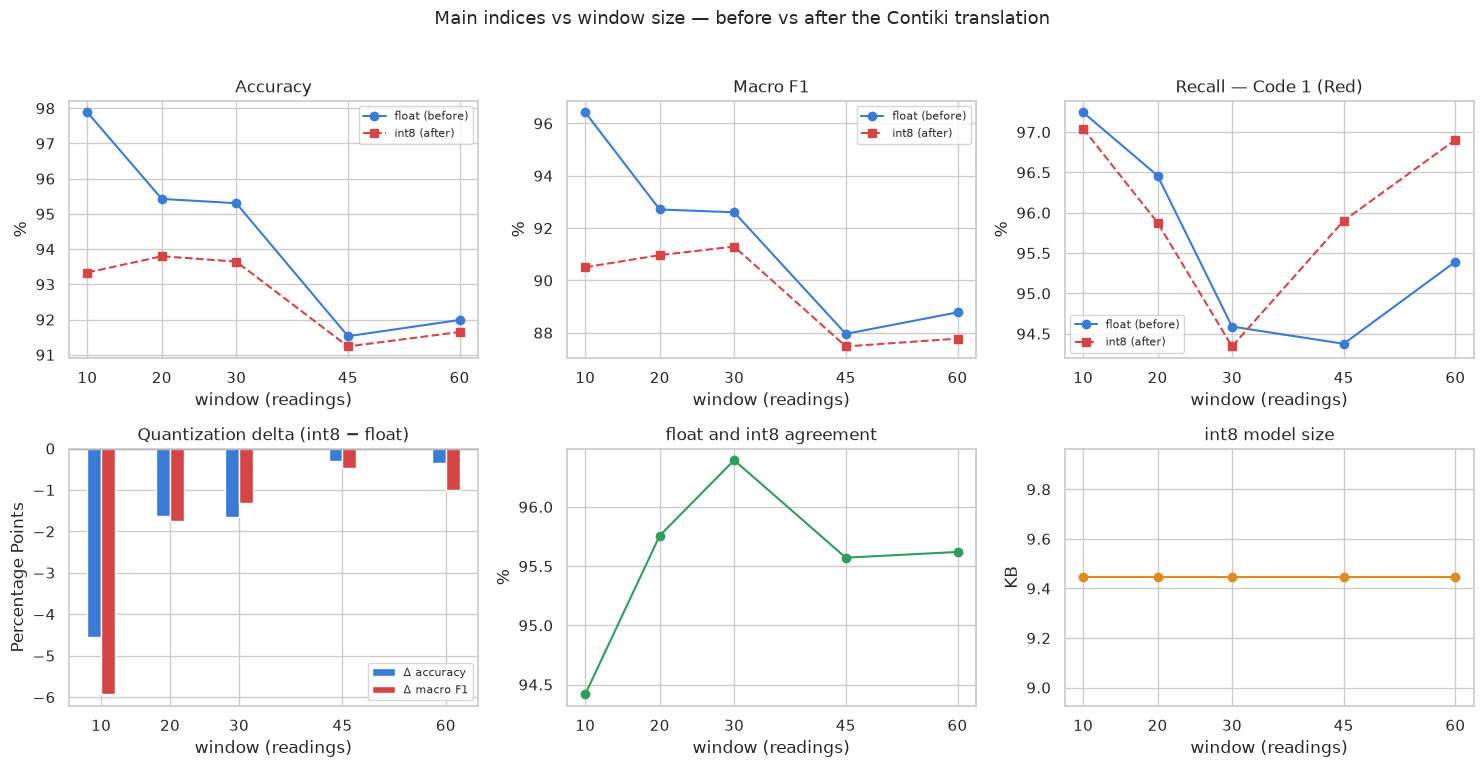

In [11]:
ws    = WINDOW_SIZES
acc_f = [results[w]['float']['accuracy'] * 100 for w in ws]
acc_q = [results[w]['int8']['accuracy']  * 100 for w in ws]
f1_f  = [results[w]['float']['f1_macro'] * 100 for w in ws]
f1_q  = [results[w]['int8']['f1_macro']  * 100 for w in ws]
red_f = [results[w]['float']['recall_per_class'][0] * 100 for w in ws]
red_q = [results[w]['int8']['recall_per_class'][0]  * 100 for w in ws]
agree = [results[w]['agreement'] * 100 for w in ws]
sizek = [results[w]['size_bytes'] / 1024 for w in ws]
d_acc = [q - f for f, q in zip(acc_f, acc_q)]
d_f1  = [q - f for f, q in zip(f1_f,  f1_q)]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))

def duo(ax, yf, yq, title):
    ax.plot(ws, yf, 'o-',  color='#3a7bd5', label='float (before)')
    ax.plot(ws, yq, 's--', color='#d64545', label='int8 (after)')
    ax.set_title(title); ax.set_xlabel('window (readings)'); ax.set_ylabel('%')
    ax.set_xticks(ws); ax.legend(fontsize=8)

duo(axes[0, 0], acc_f, acc_q, 'Accuracy')
duo(axes[0, 1], f1_f,  f1_q,  'Macro F1')
duo(axes[0, 2], red_f, red_q, 'Recall — Code 1 (Red)')

ax = axes[1, 0]
ax.bar([w - 1 for w in ws], d_acc, width=2, color='#3a7bd5', label='Δ accuracy')
ax.bar([w + 1 for w in ws], d_f1,  width=2, color='#d64545', label='Δ macro F1')
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Quantization delta (int8 − float)')
ax.set_xlabel('window (readings)');
ax.set_ylabel('Percentage Points')
ax.set_xticks(ws); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(ws, agree, 'o-', color='#2e9e5b')
ax.set_title('float and int8 agreement')
ax.set_xlabel('window (readings)'); ax.set_ylabel('%'); ax.set_xticks(ws)

ax = axes[1, 2]
ax.plot(ws, sizek, 'o-', color='#e08a1e')
ax.set_title('int8 model size')
ax.set_xlabel('window (readings)'); ax.set_ylabel('KB'); ax.set_xticks(ws)

plt.suptitle('Main indices vs window size — before vs after the Contiki translation',
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

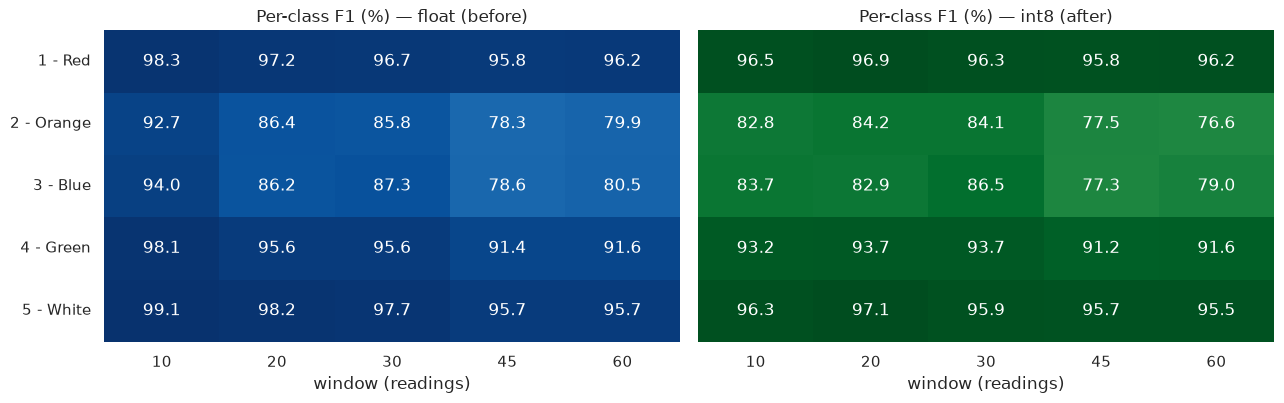

In [29]:
# Per-class F1 across window sizes, before vs after the translation
f1_float = pd.DataFrame({w: results[w]['float']['f1_per_class'] * 100 for w in ws}, index=CODE_LABELS)
f1_int8  = pd.DataFrame({w: results[w]['int8']['f1_per_class']  * 100 for w in ws}, index=CODE_LABELS)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
sns.heatmap(f1_float, annot=True, fmt='.1f', cmap='Blues',  cbar=False, vmin=0, vmax=100, ax=a1)
a1.set_title('Per-class F1 (%) — float (before)'); a1.set_xlabel('window (readings)')
sns.heatmap(f1_int8,  annot=True, fmt='.1f', cmap='Greens', cbar=False, vmin=0, vmax=100, ax=a2)
a2.set_title('Per-class F1 (%) — int8 (after)');  a2.set_xlabel('window (readings)')
plt.tight_layout(); plt.show()

## 7. Deployment for Contiki-NG — TensorFlow Lite for Microcontrollers (int8)

`emlearn` cannot export a convolutional model, so the Contiki translation uses **TFLite Micro** with **full integer (int8) post-training quantization**:

- a **representative dataset** (a few hundred training windows) lets the converter calibrate activation ranges;
- weights **and** activations become int8, and we force **int8 input/output** (`inference_input_type/output_type = tf.int8`) — required by the microcontroller runtime;
- the result is ~4× smaller and uses integer-only arithmetic (no FPU pressure).

The conversion itself already ran once per window size inside the sweep. Here we pick the window to deploy and emit **its** artifacts: standardization constants, quantization parameters, the op list for the Micro resolver, and the model as a C byte array (`triage_cnn_model.cc` — same filename the firmware already includes).

In [12]:
DEPLOY_WINDOW = 20
res = results[DEPLOY_WINDOW]

# Constants for the firmware (applied to each raw reading before it enters the window buffer).
# These are window-size specific — always regenerate them together with the model.
mean_str  = ', '.join(f'{m:.4f}f' for m in res['feat_mean'])
scale_str = ', '.join(f'{s:.4f}f' for s in res['feat_std'])
n = len(FEATURES)
print(f'=== Constants for the nRF52840 firmware (window = {DEPLOY_WINDOW} readings) ===')
print(f'/* order: {", ".join(FEATURES)} */')
print(f'#define TRIAGE_WINDOW {DEPLOY_WINDOW}')
print(f'static const float FEATURE_MEAN[{n}]  = {{ {mean_str} }};')
print(f'static const float FEATURE_SCALE[{n}] = {{ {scale_str} }};')

=== Constants for the nRF52840 firmware (window = 20 readings) ===
/* order: HR, SBP, DBP, RR, SpO2, Temp */
#define TRIAGE_WINDOW 20
static const float FEATURE_MEAN[6]  = { 32.0918f, 62.2266f, 31.8351f, 7.6565f, 30.9309f, 15.4654f };
static const float FEATURE_SCALE[6] = { 37.1271f, 49.9981f, 33.5817f, 5.9382f, 44.4924f, 11.1406f };


In [13]:
with open(res['int8_model_path'], 'rb') as f:
    tflite_model = f.read()

TFLITE_PATH = f'triage_cnn_w{DEPLOY_WINDOW}.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_bytes     = res['size_bytes']
nrf52840_flash = 1024 * 1024   # 1 MB flash
print(f'Wrote {TFLITE_PATH}')
print(f'Model size    : {size_bytes/1024:.1f} KB ({size_bytes:,} bytes)')
print(f'nRF52840 flash: {nrf52840_flash//1024} KB  ->  model uses {size_bytes/nrf52840_flash*100:.2f}%')

# Quantization parameters the firmware needs, plus the op set for the Micro resolver.
in_scale, in_zp, out_scale, out_zp = res['quant']
print('\nint8 input : scale=%.8f  zero_point=%d' % (in_scale, in_zp))
print('int8 output: scale=%.8f  zero_point=%d' % (out_scale, out_zp))

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
try:
    ops = sorted({op['op_name'] for op in interpreter._get_ops_details()} - {'DELEGATE'})
    print('\nOps to register in the TFLite Micro resolver:')
    print('  ' + ', '.join(ops))
except Exception as e:
    print(f'\n[Could not list ops on this TF version: {e}]')

# Emit the model as a C array to compile into the firmware
CC_PATH = 'triage_cnn_model.cc'
with open(CC_PATH, 'w') as f:
    f.write('#include "triage_cnn_model.h"\n\n')
    f.write('alignas(8) const unsigned char triage_cnn_model[] = {\n  ')
    f.write(',\n  '.join(
        ', '.join(f'0x{b:02x}' for b in tflite_model[k:k+12])
        for k in range(0, len(tflite_model), 12)))
    f.write('\n};\n')
    f.write(f'const unsigned int triage_cnn_model_len = {len(tflite_model)};\n')
print(f'\nWrote {CC_PATH} ({os.path.getsize(CC_PATH)/1024:.1f} KB of source)')

Wrote triage_cnn_w20.tflite
Model size    : 9.4 KB (9,672 bytes)
nRF52840 flash: 1024 KB  ->  model uses 0.92%

int8 input : scale=0.04787856  zero_point=-71
int8 output: scale=0.00390625  zero_point=-128

Ops to register in the TFLite Micro resolver:
  CONV_2D, EXPAND_DIMS, FULLY_CONNECTED, MAX_POOL_2D, MEAN, RESHAPE, SOFTMAX

Wrote triage_cnn_model.cc (58.4 KB of source)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


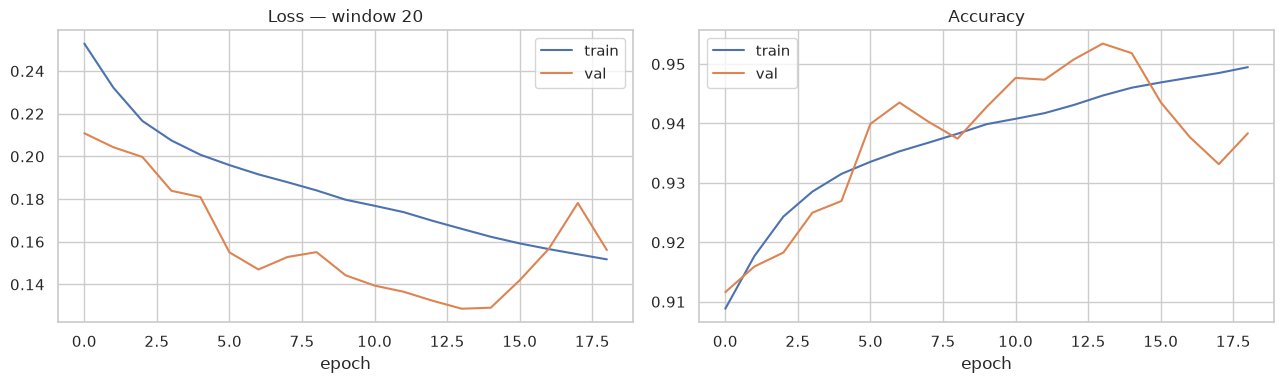

In [14]:
# Training curves of the deployed window (sanity check on convergence / overfitting)
h = res['history']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(h['loss'], label='train')
ax1.plot(h['val_loss'], label='val')
ax1.set_title(f'Loss — window {DEPLOY_WINDOW}')
ax1.set_xlabel('epoch')
ax1.legend()
ax2.plot(h['accuracy'], label='train')
ax2.plot(h['val_accuracy'], label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('epoch')
ax2.legend()
plt.tight_layout();
plt.show()

## 8. Validation of the deployed model

Last check on the chosen window, in full detail: the int8 model must track the float model closely (before vs after the translation), and the confusion matrices must stay near-diagonal. With 5 imbalanced classes, per-class precision/recall/F1 matter more than overall accuracy.

In [15]:
y_test     = res['y_test']
keras_pred = res['keras_pred']
int8_pred  = res['int8_pred']

keras_acc  = accuracy_score(y_test, keras_pred) * 100
int8_acc   = accuracy_score(y_test, int8_pred) * 100
agreement  = (keras_pred == int8_pred).mean() * 100
n_disagree = int((keras_pred != int8_pred).sum())

print(f'Deployed window         : {DEPLOY_WINDOW} readings = {DEPLOY_WINDOW * SAMPLING_INTERVAL} s')
print(f'Test windows            : {len(y_test)}')
print(f'Keras (float) accuracy  : {keras_acc:.3f}%')
print(f'TFLite (int8) accuracy  : {int8_acc:.3f}%')
print(f'Quantization delta      : {int8_acc - keras_acc:+.3f} pp')
print(f'Keras vs int8 agreement : {agreement:.3f}%')
print(f'Disagreements           : {n_disagree} / {len(y_test)}')

print('\n--- BEFORE the translation: float Keras model ---')
print(res['float']['report'])
print('--- AFTER the translation: int8 TFLite model ---')
print(res['int8']['report'])

Deployed window         : 20 readings = 20 s
Test windows            : 743877
Keras (float) accuracy  : 95.426%
TFLite (int8) accuracy  : 93.798%
Quantization delta      : -1.628 pp
Keras vs int8 agreement : 95.757%
Disagreements           : 31561 / 743877

--- BEFORE the translation: float Keras model ---
              precision    recall  f1-score   support

     1 - Red      0.980     0.965     0.972     36917
  2 - Orange      0.804     0.932     0.864     27162
    3 - Blue      0.814     0.915     0.862     71445
   4 - Green      0.971     0.941     0.956    299295
   5 - White      0.988     0.977     0.982    309058

    accuracy                          0.954    743877
   macro avg      0.912     0.946     0.927    743877
weighted avg      0.957     0.954     0.955    743877

--- AFTER the translation: int8 TFLite model ---
              precision    recall  f1-score   support

     1 - Red      0.980     0.959     0.969     36917
  2 - Orange      0.787     0.906     0.842  

In [16]:
# First 15 test windows: window-averaged features (display only) + both predictions
compare = pd.DataFrame(res['X_test_head'].mean(axis=1).round(1),
                       columns=[f + '_avg' for f in FEATURES])
compare['True']  = [CODE_LABELS[i] for i in y_test[:15]]
compare['Keras'] = [CODE_LABELS[i] for i in keras_pred[:15]]
compare['int8']  = [CODE_LABELS[i] for i in int8_pred[:15]]
compare['match'] = np.where(keras_pred[:15] == int8_pred[:15], 'OK', 'DIFF')
compare

,HR_avg,SBP_avg,DBP_avg,RR_avg,SpO2_avg,Temp_avg,True,Keras,int8,match
0,69.699997,96.800003,54.700001,14.0,85.000000,36.500000,3 - Blue,3 - Blue,3 - Blue,OK
1,89.199997,148.199997,85.400002,13.0,99.400002,22.500000,4 - Green,4 - Green,4 - Green,OK
2,89.800003,87.000000,44.599998,14.0,100.000000,37.299999,4 - Green,4 - Green,4 - Green,OK
3,86.199997,89.400002,43.700001,13.0,100.000000,35.299999,4 - Green,4 - Green,4 - Green,OK
4,65.800003,88.400002,54.799999,11.0,100.000000,35.700001,3 - Blue,3 - Blue,3 - Blue,OK
5,65.199997,129.800003,66.599998,16.0,99.599998,36.200001,5 - White,5 - White,5 - White,OK
6,75.099998,111.500000,63.599998,14.0,100.000000,36.500000,5 - White,5 - White,5 - White,OK
7,104.000000,115.599998,44.599998,12.0,100.000000,35.900002,4 - Green,4 - Green,4 - Green,OK
8,81.599998,99.000000,61.900002,15.0,99.599998,22.700001,3 - Blue,3 - Blue,3 - Blue,OK
9,68.099998,116.699997,81.500000,14.0,100.000000,35.000000,4 - Green,4 - Green,5 - White,DIFF


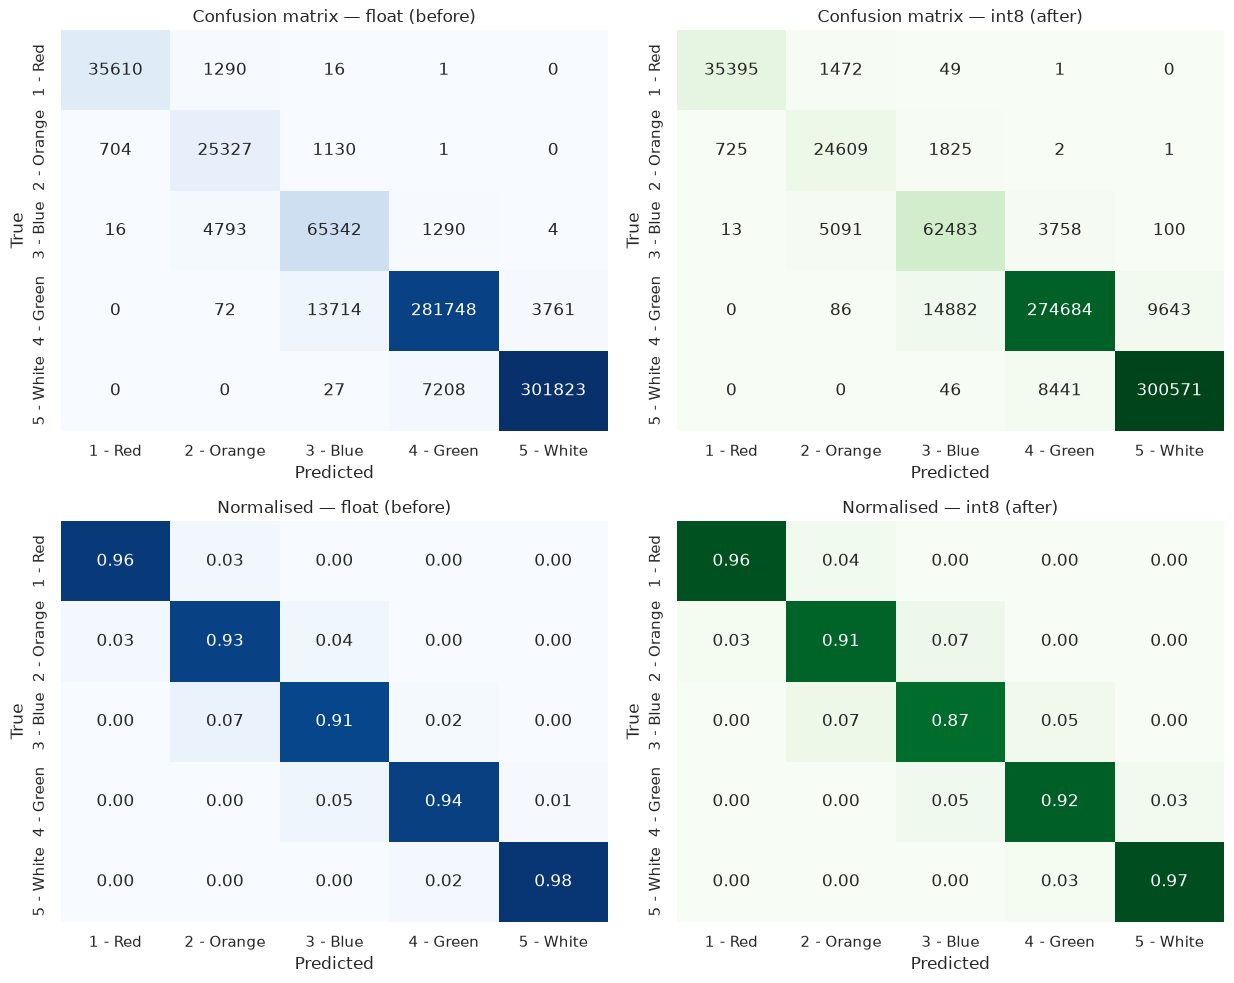

In [20]:
fig, axes2 = plt.subplots(2, 2, figsize=(12.5, 10))

for col, (pred, name, cmapc) in enumerate([
        (keras_pred, 'float (before)', 'Blues'),
        (int8_pred,  'int8 (after)',   'Greens')]):

    cm = confusion_matrix(y_test, pred, labels=range(len(CODE_LABELS)))

    # Row-normalised
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    # Top row: absolute counts
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmapc,
                xticklabels=CODE_LABELS, yticklabels=CODE_LABELS,
                cbar=False, ax=axes2[0, col])
    axes2[0, col].set_xlabel('Predicted'); axes2[0, col].set_ylabel('True')
    axes2[0, col].set_title(f'Confusion matrix — {name}')

    # Bottom row: same data, row-normalised
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmapc, vmin=0, vmax=1,
                xticklabels=CODE_LABELS, yticklabels=CODE_LABELS,
                cbar=False, ax=axes2[1, col])
    axes2[1, col].set_xlabel('Predicted'); axes2[1, col].set_ylabel('True')
    axes2[1, col].set_title(f'Normalised — {name}')

plt.tight_layout(); plt.show()

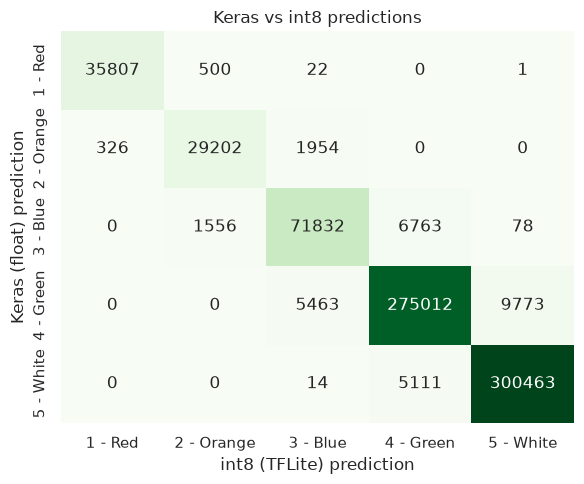

Accuracy retained : 93.80% vs 95.43% (drop +1.63 pp)
Disagreements     : 31561  ->  adjacent-code: 31446, multi-code jump: 115


In [21]:
# Keras-vs-int8 confusion: near-diagonal means the quantized model tracks the float model.
cm_ki = confusion_matrix(keras_pred, int8_pred, labels=range(len(CODE_LABELS)))
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ki, annot=True, fmt='d', cmap='Greens',
            xticklabels=CODE_LABELS, yticklabels=CODE_LABELS, cbar=False)
plt.xlabel('int8 (TFLite) prediction'); plt.ylabel('Keras (float) prediction')
plt.title('Keras vs int8 predictions')
plt.tight_layout(); plt.show()

diff_mask = keras_pred != int8_pred
adj_flips = int((np.abs(keras_pred - int8_pred) == 1).sum())
far_flips = int((np.abs(keras_pred - int8_pred) >= 2).sum())
acc_drop  = keras_acc - int8_acc          # positive => int8 is worse

print(f'Accuracy retained : {int8_acc:.2f}% vs {keras_acc:.2f}% (drop {acc_drop:+.2f} pp)')
print(f'Disagreements     : {int(diff_mask.sum())}  ->  adjacent-code: {adj_flips}, '
      f'multi-code jump: {far_flips}')

# Estimate the on-device simulator parameters (baseline / noise_amp / pull_pct)

The firmware fakes vitals with a mean-reverting AR(1) step:
$$
    next = current + (baseline - current) * pull\_pct/100 + noise
$$
Rather than picking those three numbers by eye, derive them from VitalDB.

In [ ]:
# BASELINES

# Pooled across all cases. The MEDIAN is used rather than the mean: it is
# robust to whatever junk survives the mask, and it is the value a "typical"
# patient sits at.
all_rows = pd.DataFrame(np.vstack(series), columns=FEATURES)

baseline = all_rows.median()

# Step-to-step noise and persistence

# noise_amp and pull_pct describe how ONE patient moves between TWO CONSECUTIVE
# readings - not how patients differ from each other. So both are computed
# per case and then pooled, never on the flattened population:
#
#   noise_amp : std of the first differences (how big a single step is)
#   phi       : lag-1 autocorrelation (how much a reading remembers the previous)
#
# Cases are masked individually so that a gap does not create a fake jump
# between the values on either side of it.
diff_chunks, phi_rows = [], []

for s_arr in series:
    df_case = pd.DataFrame(s_arr, columns=FEATURES)
    diff_chunks.append(np.diff(df_case.to_numpy(), axis=0))
    phi_rows.append([df_case[f].autocorr(lag=1) for f in FEATURES])

diffs = pd.DataFrame(np.vstack(diff_chunks), columns=FEATURES)
noise_std = diffs.std()

phi = pd.Series(np.nanmean(np.asarray(phi_rows, dtype=float), axis=0), index=FEATURES)
pull_pct = ((1 - phi) * 100).clip(lower=0, upper=100)

# summary
params = pd.DataFrame({
    'baseline'        : baseline.round(2),
    'noise_std'       : noise_std.round(3),                 # use directly with gaussian noise
    'noise_amp_unif'  : (noise_std * np.sqrt(3)).round(3),  # equivalent uniform half-width, needed for the uniform generation
    'phi_lag1'        : phi.round(4),
    'pull_pct'        : pull_pct.round(1),
})

print(f'\nEstimated at the cached sampling interval of {SAMPLING_INTERVAL}s '
      '- the firmware must publish at this same interval for these numbers to hold.')
print(params)


Estimated at the cached sampling interval of 1s - the firmware must publish at this same interval for these numbers to hold.
        baseline  noise_std  noise_amp_unif  phi_lag1  pull_pct
HR     72.000000      1.889           3.271    0.9866       1.3
SBP   115.000000      3.969           6.874    0.9935       0.6
DBP    61.000000      3.653           6.328    0.9887       1.1
RR     14.000000      0.267           0.462    0.9973       0.3
SpO2  100.000000      0.289           0.500    0.9883       1.2
Temp   35.700001      0.172           0.298    0.9973       0.3
